==== Ridge 岭回归 ====
系数coef_： [ 2.03962916  0.89765764 -0.11517251]
截距intercept_： -0.0020702136420460704
R²分数： 0.9644214963282789

==== Lasso 拉索回归 ====
系数coef_： [ 2.42146463  0.         -0.        ]
截距intercept_： 0.27142056070318077
R²分数： 0.9654619852881222


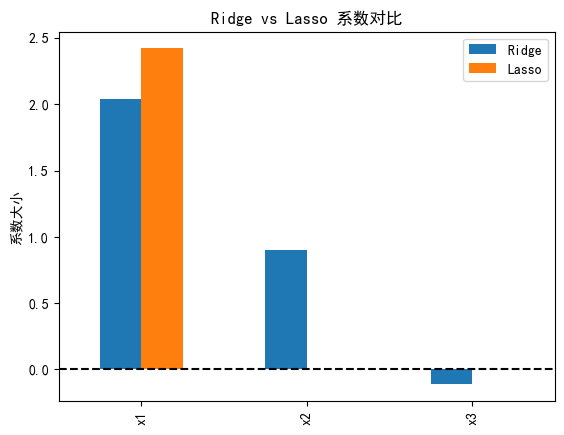

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ========= Windows中文设置，只保留SimHei =========
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False

# 构造模拟经济学数据：自变量x1,x2,x3；y为需求量
np.random.seed(42)
n = 50
x1 = np.linspace(0, 10, n)
x2 = 0.5 * x1 + np.random.randn(n)*0.3  # 和x1多重共线性
x3 = np.random.randn(n)
y = 2 * x1 + 1 * x2 + 0 * x3 + np.random.randn(n)*0.8

X = pd.DataFrame({"x1":x1,"x2":x2,"x3":x3})

# 划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# ========== Ridge岭回归 ==========
ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
y_pred_ridge = ridge.predict(X_test)
print("==== Ridge 岭回归 ====")
print("系数coef_：", ridge.coef_)
print("截距intercept_：", ridge.intercept_)
print("R²分数：", r2_score(y_test,y_pred_ridge))

# ========== Lasso拉索回归 ==========
lasso = Lasso(alpha=0.5)
lasso.fit(X_train,y_train)
y_pred_lasso = lasso.predict(X_test)
print("\n==== Lasso 拉索回归 ====")
print("系数coef_：", lasso.coef_)
print("截距intercept_：", lasso.intercept_)
print("R²分数：", r2_score(y_test,y_pred_lasso))

# 画图对比两个模型系数
coef_df = pd.DataFrame({
    "Ridge":ridge.coef_,
    "Lasso":lasso.coef_
}, index=["x1","x2","x3"])
coef_df.plot(kind="bar")
plt.title("Ridge vs Lasso 系数对比")
plt.axhline(y=0,color="black",linestyle="--")
plt.ylabel("系数大小")
plt.show()